# 01 - Analyse exploratoire des données

Objectif : explorer les données du projet Home Credit Default Risk pour préparer la modélisation de scoring crédit.

Inspiré du kernel Kaggle [Start Here: A Gentle Introduction](https://www.kaggle.com/code/willkoehrsen/start-here-a-gentle-introduction/notebook) de Will Koehrsen, adapté et simplifié pour notre mission.

On regarde principalement :
- la table `application_train` (table principale, contient la cible `TARGET`)
- la distribution de la cible et le déséquilibre des classes
- les valeurs manquantes
- les doublons
- les anomalies évidentes
- un aperçu rapide des autres tables qu'on utilisera pour le feature engineering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

DATA_DIR = '../data/raw/'

## 1. Chargement de la table principale

`application_train.csv` est la table pivot : une ligne = un dossier de demande de crédit, `TARGET = 1` si le client a eu des difficultés à rembourser, `0` sinon.

In [2]:
app_train = pd.read_csv(DATA_DIR + 'application_train.csv')
print(f"Shape : {app_train.shape}")
app_train.head()

Shape : (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
app_train.info(verbose=False)

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


## 2. Distribution de la cible (TARGET)

On regarde si les classes sont équilibrées ou non. Si elles sont déséquilibrées, il faudra en tenir compte au moment de l'entraînement.

Effectifs :
TARGET
0    282686
1     24825
Name: count, dtype: int64

Pourcentages :
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


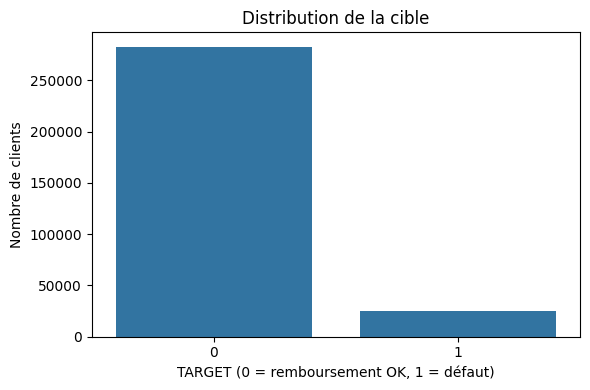

In [4]:
target_counts = app_train['TARGET'].value_counts()
target_pct = app_train['TARGET'].value_counts(normalize=True) * 100

print("Effectifs :")
print(target_counts)
print("\nPourcentages :")
print(target_pct.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=app_train, x='TARGET', ax=ax)
ax.set_title('Distribution de la cible')
ax.set_xlabel('TARGET (0 = remboursement OK, 1 = défaut)')
ax.set_ylabel('Nombre de clients')
plt.tight_layout()
plt.show()

**Observation :** la cible est très déséquilibrée (environ 92% de 0 contre 8% de 1). Il faudra gérer ce déséquilibre dans la modélisation (par exemple via `class_weight='balanced'` ou `scale_pos_weight` selon le modèle).

## 3. Doublons

On vérifie qu'il n'y a pas de doublons dans la table, ni sur la clé `SK_ID_CURR` ni sur les lignes complètes.

In [5]:
print(f"Doublons sur SK_ID_CURR : {app_train['SK_ID_CURR'].duplicated().sum()}")
print(f"Doublons sur lignes complètes : {app_train.duplicated().sum()}")

Doublons sur SK_ID_CURR : 0
Doublons sur lignes complètes : 0


## 4. Valeurs manquantes

On regarde combien de colonnes ont des valeurs manquantes et dans quelles proportions.

In [6]:
missing = app_train.isnull().sum()
missing_pct = (missing / len(app_train) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False)

print(f"Colonnes avec valeurs manquantes : {len(missing_df)} sur {app_train.shape[1]}")
missing_df.head(20)

Colonnes avec valeurs manquantes : 67 sur 122


,count,pct
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


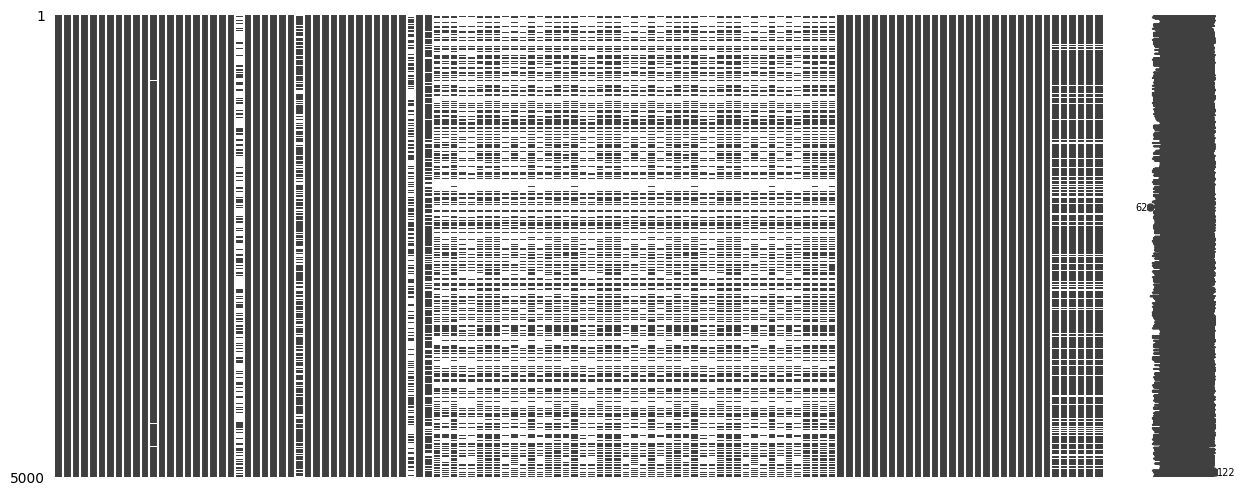

In [7]:
# Visualisation matricielle des valeurs manquantes (sur un échantillon pour la lisibilité)
msno.matrix(app_train.sample(5000, random_state=42), figsize=(15, 6), fontsize=8)
plt.show()

**Observation :** beaucoup de colonnes ont des valeurs manquantes, parfois à plus de 50%. On voit notamment des blocs de colonnes qui manquent ensemble (informations sur le logement par exemple). 

**Décision :** on ne supprime pas les colonnes maintenant. On va les laisser dans le dataset et gérer l'imputation au moment de l'entraînement, dans un `Pipeline` scikit-learn. Cela permet d'éviter le data leakage en cross-validation : la statistique d'imputation (médiane par exemple) est calculée uniquement sur le fold de train à chaque itération.

## 5. Anomalies

Le kernel de Koehrsen signale une anomalie sur `DAYS_EMPLOYED` : la valeur 365243 (qui correspondrait à environ 1000 ans d'emploi) est en fait un code pour signifier "non renseigné". On vérifie.

Statistiques sur DAYS_EMPLOYED :
count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

Nombre de lignes avec DAYS_EMPLOYED == 365243 : 55374


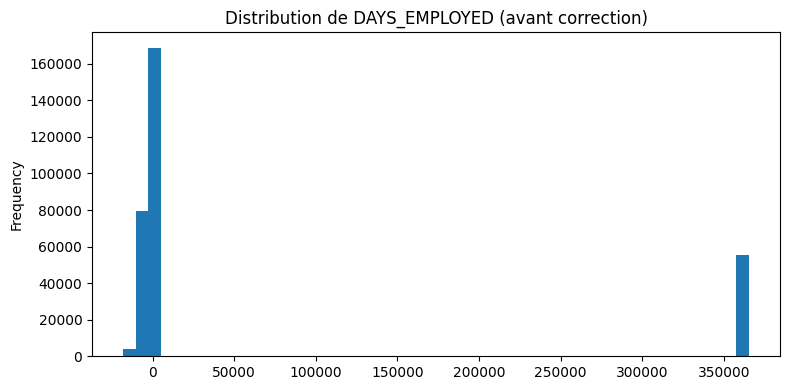

In [8]:
print("Statistiques sur DAYS_EMPLOYED :")
print(app_train['DAYS_EMPLOYED'].describe())
print(f"\nNombre de lignes avec DAYS_EMPLOYED == 365243 : {(app_train['DAYS_EMPLOYED'] == 365243).sum()}")

fig, ax = plt.subplots(figsize=(8, 4))
app_train['DAYS_EMPLOYED'].plot.hist(bins=50, ax=ax)
ax.set_title("Distribution de DAYS_EMPLOYED (avant correction)")
plt.tight_layout()
plt.show()

**Confirmation :** on voit clairement le pic anormal à 365243. On remplacera cette valeur par `NaN` au moment du feature engineering (notebook 02).

## 6. Types de variables

Combien de numériques, combien de catégorielles ?

In [9]:
dtypes_count = app_train.dtypes.value_counts()
print("Répartition des types :")
print(dtypes_count)

cat_cols = app_train.select_dtypes(include='object').columns.tolist()
print(f"\nColonnes catégorielles ({len(cat_cols)}) :")
print(cat_cols)

Répartition des types :
float64    65
int64      41
str        16
Name: count, dtype: int64

Colonnes catégorielles (16) :
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [10]:
# Nombre de modalités par variable catégorielle
for col in cat_cols:
    print(f"{col}: {app_train[col].nunique()} modalités")

NAME_CONTRACT_TYPE: 2 modalités
CODE_GENDER: 3 modalités
FLAG_OWN_CAR: 2 modalités
FLAG_OWN_REALTY: 2 modalités
NAME_TYPE_SUITE: 7 modalités
NAME_INCOME_TYPE: 8 modalités
NAME_EDUCATION_TYPE: 5 modalités
NAME_FAMILY_STATUS: 6 modalités
NAME_HOUSING_TYPE: 6 modalités
OCCUPATION_TYPE: 18 modalités
WEEKDAY_APPR_PROCESS_START: 7 modalités
ORGANIZATION_TYPE: 58 modalités
FONDKAPREMONT_MODE: 4 modalités
HOUSETYPE_MODE: 3 modalités
WALLSMATERIAL_MODE: 7 modalités
EMERGENCYSTATE_MODE: 2 modalités


**Observation :** la plupart des catégorielles ont peu de modalités (< 10), on pourra utiliser un one-hot encoding sans exploser la dimensionnalité.

## 7. Aperçu rapide des autres tables

On charge brièvement les autres tables pour confirmer leur structure et la clé de jointure.

In [11]:
descriptions = {
    'bureau.csv': "Crédits du client auprès d'autres institutions, déclarés au Credit Bureau",
    'bureau_balance.csv': "Historique mensuel des crédits du Bureau (jointure via SK_ID_BUREAU)",
    'previous_application.csv': "Demandes de crédit précédentes du client chez Home Credit",
    'POS_CASH_balance.csv': "Historique mensuel des crédits POS et cash chez Home Credit",
    'installments_payments.csv': "Historique de remboursement (un paiement = une ligne)",
    'credit_card_balance.csv': "Historique mensuel des cartes de crédit chez Home Credit",
}

for filename, desc in descriptions.items():
    df = pd.read_csv(DATA_DIR + filename)
    print(f"--- {filename} ---")
    print(f"  {desc}")
    print(f"  Shape : {df.shape}")
    print(f"  Colonnes : {list(df.columns)}")
    print()
    del df

--- bureau.csv ---
  Crédits du client auprès d'autres institutions, déclarés au Credit Bureau
  Shape : (1716428, 17)
  Colonnes : ['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'DAYS_CREDIT', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'AMT_ANNUITY']

--- bureau_balance.csv ---
  Historique mensuel des crédits du Bureau (jointure via SK_ID_BUREAU)
  Shape : (27299925, 3)
  Colonnes : ['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']

--- previous_application.csv ---
  Demandes de crédit précédentes du client chez Home Credit
  Shape : (1670214, 37)
  Colonnes : ['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'FLAG_LAST_APPL_PER_CO

**Note :** ces tables ne sont pas analysées en détail ici. Elles seront agrégées dans le notebook 02 (une ligne par client, jointe sur `SK_ID_CURR`) pour enrichir la table principale.

**Observation :** toutes les tables sont reliées à la table principale via `SK_ID_CURR`, sauf `bureau_balance` qui se joint à `bureau` via `SK_ID_BUREAU`. La structure correspond à ce qui est décrit dans la documentation Kaggle.

## 8. Corrélations avec la cible

On regarde quelles variables numériques sont les plus liées à `TARGET`. Ça nous donne une idée des features les plus prometteuses avant même de modéliser.

In [12]:
correlations = app_train.corr(numeric_only=True)['TARGET'].sort_values()

print("Top 10 corrélations négatives (associées à un meilleur remboursement) :")
print(correlations.head(10))

print("\nTop 10 corrélations positives (associées au défaut) :")
print(correlations.tail(11).head(10))  # head(10) après tail(11) pour exclure TARGET=1

Top 10 corrélations négatives (associées à un meilleur remboursement) :
EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
Name: TARGET, dtype: float64

Top 10 corrélations positives (associées au défaut) :
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
Name: TARGET, dtype: float64


**Observation :** les variables `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` (scores externes fournis dans les données) ressortent comme les plus négativement corrélées avec le défaut : plus le score externe est élevé, moins il y a de risque. Ce sont probablement les features les plus importantes du futur modèle.

`DAYS_BIRTH` est positivement corrélée : attention, comme c'est une valeur en jours négatifs (date de naissance par rapport à la date de demande), une valeur plus proche de 0 = client plus jeune = plus de risque. Ça correspond à l'intuition métier (les jeunes ont moins d'historique de crédit).

## Synthèse

Ce qu'on retient pour la suite :

- **Volume :** ~307k lignes dans `application_train`, 122 colonnes
- **Déséquilibre des classes :** ~92% / 8% → à gérer dans la modélisation
- **Pas de doublons** à traiter
- **Valeurs manquantes nombreuses** → imputation au moment de l'entraînement (dans un `Pipeline` pour éviter le data leakage)
- **Anomalie `DAYS_EMPLOYED = 365243`** → à remplacer par `NaN`
- **Catégorielles compatibles avec un one-hot encoding** (peu de modalités)
- **6 tables annexes** à joindre via `SK_ID_CURR` (et `SK_ID_BUREAU` pour `bureau_balance`)

On passe au notebook 02 pour le feature engineering et la fusion des tables.